In [51]:
import numpy as np
import pandas as pd
import seaborn as sns

In [52]:
df = pd.read_csv("../Data/titanic_train.csv")

In [53]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [54]:
df.isnull().mean()*100 

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


C:\Users\gdeep\AppData\Local\Temp\ipykernel_18400\4172352170.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df , x= 'Survived' , palette="RdBu_r")


<Axes: xlabel='Survived', ylabel='count'>

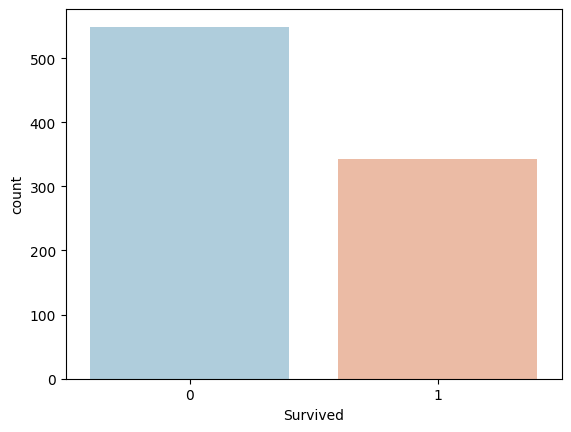

In [56]:
sns.countplot(data = df , x= 'Survived' , palette="RdBu_r")

C:\Users\gdeep\AppData\Local\Temp\ipykernel_18400\1068425276.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Age'] , kde = True , bins = 25 , color= 'darkred')


<Axes: xlabel='Age', ylabel='Density'>

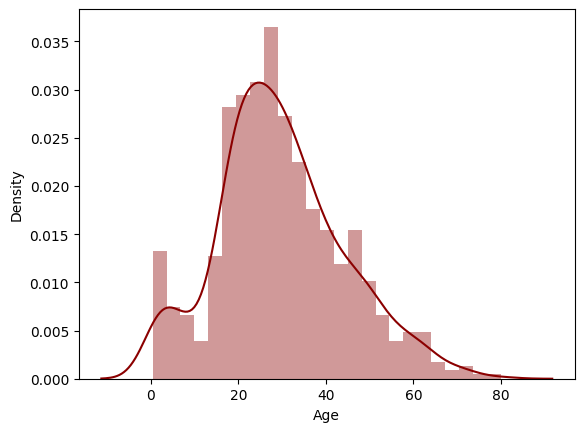

In [57]:
sns.distplot(df['Age'] , kde = True , bins = 25 , color= 'darkred')

In [58]:
df['Alone'] = df['SibSp'] + df['Parch']

In [59]:
df['Alone'] =  df['Alone'].apply(lambda x : 1 if x>0 else 0)

In [60]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Alone'],
      dtype='object')

In [61]:
X = df.drop(columns = ['PassengerId' , 'Survived' , 'Name' , 'SibSp' , 'Parch' , 'Ticket' , "Cabin"])
y = df['Survived']


In [62]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    object 
 2   Age       714 non-null    float64
 3   Fare      891 non-null    float64
 4   Embarked  889 non-null    object 
 5   Alone     891 non-null    int64  
dtypes: float64(2), int64(2), object(2)
memory usage: 41.9+ KB


In [63]:
from sklearn.model_selection import train_test_split
X_train ,X_test ,y_train ,y_test = train_test_split(X, y , test_size=0.2)

In [64]:
categorical_feature = ['Sex' , 'Embarked']
numerical_feature = ['Age' , 'Fare']



In [65]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler , OneHotEncoder 
from sklearn.impute import SimpleImputer

numerical_pipeline = Pipeline([
    ("impute" , SimpleImputer(strategy="mean")),
    ("scale" , StandardScaler())
])

trf = ColumnTransformer([
    ('numerical' , numerical_pipeline , numerical_feature ),
    ("categorical" , OneHotEncoder(handle_unknown="ignore" , drop="first") , categorical_feature)
], remainder= "passthrough")

In [66]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression()
lr.fit(X_train_transformed , y_train)
y_pred = lr.predict(X_test_transformed)

print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.79      0.89      0.83       105
           1       0.80      0.66      0.73        74

    accuracy                           0.79       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.79      0.79      0.79       179

